# 04. CNN Inference — Weight-Only Load

`state_dict` (weights only) save ထားတဲ့ `.pth` file ကို load ပြီး inference လုပ်မယ်။

**Weight-only save/load ရဲ့ အားသာချက်:**
- File size သေးတယ်
- PyTorch version ပြောင်းလဲမှုကို ပိုခံနိုင်တယ်
- Architecture ကို ကိုယ်တိုင် define ရတယ် (flexibility ရတယ်)

**Weight-only save/load ရဲ့ အားနည်းချက်:**
- Model class definition ရှိမှ load လို့ရတယ်
- Architecture ကိုပါ code ထဲမှာ ထိန်းသိမ်းထားရတယ်

In [1]:
# --- 1. Imports ---
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# --- 2. Device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
# --- 3. Dataset Config (training နဲ့ တူညီရမယ်) ---
DATASET_NAME = 'FashionMNIST'
IMG_SIZE = 28
IN_CHANNELS = 1  # original channels (grayscale)
NUM_CLASSES = 10

CLASS_NAMES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Grayscale → 3-channel replicate (training အတိုင်း)
MEAN = (0.2860, 0.2860, 0.2860)
STD = (0.3530, 0.3530, 0.3530)

In [5]:
# --- 4. CNN Model Definition (training notebook နဲ့ အတူတူပဲ ဖြစ်ရမယ်) ---
# ⚠️ Weight-only load ဆိုတော့ model architecture ကို ဒီမှာ ပြန် define ရတယ်
class CNN(nn.Module):
    def __init__(self, in_channels=3, num_classes=10):
        super(CNN, self).__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25)
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25)
        )

        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25)
        )

        self.pool = nn.AdaptiveAvgPool2d(4)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x

print("CNN class defined.")

CNN class defined.


In [6]:
# --- 5. Load Weights into Model ---
# Model instance ဆောက်ပြီး saved weights load မယ်
model = CNN(in_channels=3, num_classes=NUM_CLASSES).to(device)

weights_path = f"weights_cnn_{DATASET_NAME.lower()}.pth"
model.load_state_dict(torch.load(weights_path, map_location=device, weights_only=True))
model.eval()

print(f"Weights loaded from: {weights_path}")
print(f"Model is in eval mode: {not model.training}")

Weights loaded from: weights_cnn_fashionmnist.pth
Model is in eval mode: True


In [7]:
# --- 6. Image Preprocessing Function ---
# Device path ကနေ photo ကိုယူပြီး model input format ပြောင်းမယ်
def preprocess_image(image_path):
    """Load image from path and preprocess for inference."""
    img = Image.open(image_path).convert('RGB')  # 3-channel ပြောင်း

    transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(MEAN, STD)
    ])

    tensor = transform(img).unsqueeze(0)  # (1, 3, H, W) batch dimension ထည့်
    return img, tensor

In [9]:
# --- 7. Inference Function ---
def predict(image_path):
    """Run inference on a single image and return results."""
    original_img, input_tensor = preprocess_image(image_path)
    input_tensor = input_tensor.to(device)

    with torch.no_grad():
        logits = model(input_tensor)
        probabilities = torch.softmax(logits, dim=1)
        predicted_class = torch.argmax(probabilities, dim=1).item()
        confidence = probabilities[0, predicted_class].item()

    return {
        'original_img': original_img,
        'predicted_class': predicted_class,
        'class_name': CLASS_NAMES[predicted_class],
        'confidence': confidence,
        'probabilities': probabilities[0].cpu().numpy(),
        'logits': logits[0].cpu().numpy()
    }

In [15]:
# --- 8. Run Inference ---
# ⬇️ ဒီမှာ ကိုယ့် image path ထည့်ပါ
IMAGE_PATH = r"Minimalist.webp"  # <-- ဒီမှာ ပြောင်းပါ

result = predict(IMAGE_PATH)

print("=" * 50)
print(f"Predicted Class: {result['class_name']}")
print(f"Confidence: {result['confidence']:.4f} ({result['confidence']*100:.1f}%)")
print("=" * 50)

Predicted Class: Bag
Confidence: 0.7780 (77.8%)


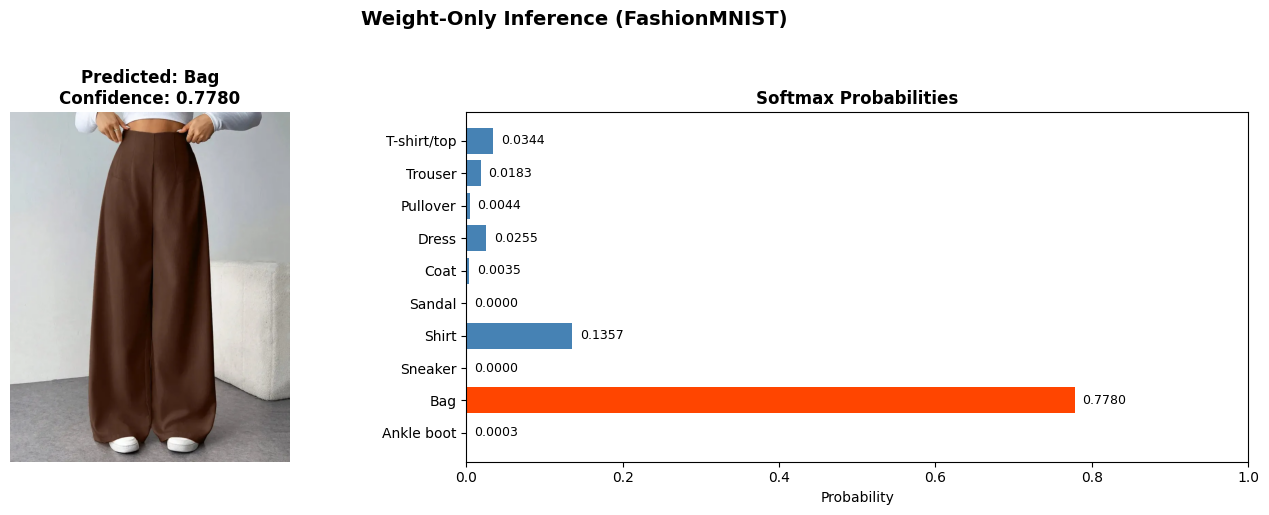

In [16]:
# --- 9. Visualize Results ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5),
                         gridspec_kw={'width_ratios': [1, 1.5]})

# (1) Original Image
axes[0].imshow(result['original_img'])
axes[0].set_title(f"Predicted: {result['class_name']}\n"
                  f"Confidence: {result['confidence']:.4f}",
                  fontsize=12, fontweight='bold')
axes[0].axis('off')

# (2) Probability Bar Chart
probs = result['probabilities']
colors = ['orangered' if i == result['predicted_class'] else 'steelblue'
          for i in range(NUM_CLASSES)]
axes[1].barh(CLASS_NAMES, probs, color=colors)
axes[1].set_xlabel('Probability')
axes[1].set_title('Softmax Probabilities', fontsize=12, fontweight='bold')
axes[1].set_xlim(0, 1)
axes[1].invert_yaxis()
for i, v in enumerate(probs):
    axes[1].text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=9)

plt.suptitle(f"Weight-Only Inference ({DATASET_NAME})",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()